In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


Chase = pd.read_excel('Chase Dataset.xlsx')


Chase.head()


,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,Zipcode,Latitude,Longitude,2010 Deposits,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits
0,JPMorgan Chase Bank,1,JPMorgan Chase Bank Main Office,0,01/01/1824,NaN,1111 Polaris Parkway,Columbus,Delaware,OH,43240,40.14453,-82.99115,633131000.0,743268000.0,832455000.0,916543000.0,1.032549e+09,1.069425e+09,1155185000
1,JPMorgan Chase Bank,0,Vernon Hills Scarsdale Branch,2,03/20/1961,NaN,676 White Plains Road,Scarsdale,Westchester,NY,10583,40.97008,-73.80670,293229.0,310791.0,325742.0,327930.0,3.277920e+05,3.414750e+05,381558
2,JPMorgan Chase Bank,0,Great Neck Northern Boulevard Branch,3,1963-09-09 00:00:00,NaN,410 Northern Boulevard,Great Neck,Nassau,NY,11021,40.77944,-73.72240,191011.0,206933.0,216439.0,237983.0,2.341830e+05,2.624550e+05,278940
3,JPMorgan Chase Bank,0,North Hartsdale Branch,4,02/19/1966,NaN,353 North Central Avenue,Hartsdale,Westchester,NY,10530,41.02654,-73.79168,87110.0,88367.0,93163.0,109659.0,1.119850e+05,1.167720e+05,140233
4,JPMorgan Chase Bank,0,Lawrence Rockaway Branch,5,01/16/1965,NaN,335 Rockaway Turnpike,Lawrence,Nassau,NY,11559,40.62715,-73.73675,172608.0,172749.0,189413.0,198445.0,2.051980e+05,2.232000e+05,235594


Identifying the Data Types, here we're identifying what to standardize proper Data Types

In [3]:
Chase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5413 entries, 0 to 5412
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Institution Name  5413 non-null   object 
 1   Main Office       5413 non-null   int64  
 2   Branch Name       5413 non-null   object 
 3   Branch Number     5413 non-null   int64  
 4   Established Date  5413 non-null   object 
 5   Acquired Date     3798 non-null   object 
 6   Street Address    5413 non-null   object 
 7   City              5413 non-null   object 
 8   County            5413 non-null   object 
 9   State             5413 non-null   object 
 10  Zipcode           5413 non-null   int64  
 11  Latitude          5347 non-null   float64
 12  Longitude         5347 non-null   float64
 13  2010 Deposits     4673 non-null   float64
 14  2011 Deposits     4835 non-null   float64
 15  2012 Deposits     5084 non-null   float64
 16  2013 Deposits     5238 non-null   float64


Entries(Rows), Columns

In [4]:
Chase.shape

(5413, 20)

Defining a funstion that allows to Drop/clean the blanks and duplicates from the dataset 

In [5]:
def cleand_data(Chase):
    Chase.dropna(inplace=True)

    Chase.drop_duplicates(inplace=True)

    return Chase

Chase = cleand_data(Chase)
Chase.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3784 entries, 72 to 4483
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Institution Name  3784 non-null   object 
 1   Main Office       3784 non-null   int64  
 2   Branch Name       3784 non-null   object 
 3   Branch Number     3784 non-null   int64  
 4   Established Date  3784 non-null   object 
 5   Acquired Date     3784 non-null   object 
 6   Street Address    3784 non-null   object 
 7   City              3784 non-null   object 
 8   County            3784 non-null   object 
 9   State             3784 non-null   object 
 10  Zipcode           3784 non-null   int64  
 11  Latitude          3784 non-null   float64
 12  Longitude         3784 non-null   float64
 13  2010 Deposits     3784 non-null   float64
 14  2011 Deposits     3784 non-null   float64
 15  2012 Deposits     3784 non-null   float64
 16  2013 Deposits     3784 non-null   float64
 17 

Converting some of the fields with their proper Data types:

Established Date → datetime
Acquired Date → datetime

These are repeating labels → better as category:
Institution Name,
Branch Name,
City,
County,
State

In [6]:
def convert_data(Chase):
    Chase['Established Date'] = pd.to_datetime(Chase['Established Date'], errors='coerce')
    Chase['Acquired Date'] = pd.to_datetime(Chase['Acquired Date'], errors='coerce')
    col = ['Institution Name', 'Branch Name', 'City', 'County', 'State']
    for col in col:
        Chase[col] = Chase[col].astype('category')
    return Chase

Chase = convert_data(Chase)
Chase.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3784 entries, 72 to 4483
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Institution Name  3784 non-null   category      
 1   Main Office       3784 non-null   int64         
 2   Branch Name       3784 non-null   category      
 3   Branch Number     3784 non-null   int64         
 4   Established Date  3784 non-null   datetime64[ns]
 5   Acquired Date     3784 non-null   datetime64[ns]
 6   Street Address    3784 non-null   object        
 7   City              3784 non-null   category      
 8   County            3784 non-null   category      
 9   State             3784 non-null   category      
 10  Zipcode           3784 non-null   int64         
 11  Latitude          3784 non-null   float64       
 12  Longitude         3784 non-null   float64       
 13  2010 Deposits     3784 non-null   float64       
 14  2011 Deposits     3784 non-n

View

In [7]:
#Branch Age (from Established Date)
Chase['Branch_Age'] = 2016 - Chase['Established Date'].dt.year
Chase.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,Latitude,Longitude,2010 Deposits,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age
72,JPMorgan Chase Bank,0,Amityville Driveup Branch,174,1954-06-14,1975-01-18,4 John St,Amityville,Suffolk,NY,...,40.67894,-73.41969,93106.0,92272.0,96994.0,118907.0,115708.0,120730.0,125922,62
73,JPMorgan Chase Bank,0,Babylon Branch,176,1955-07-03,1975-01-18,31 West Main Street,Babylon,Suffolk,NY,...,40.69642,-73.32368,261976.0,262704.0,261589.0,289395.0,281756.0,292377.0,314562,61
74,JPMorgan Chase Bank,0,Center Moriches Main St Branch,178,1955-07-11,1975-01-18,366 Main St,Center Moriches,Suffolk,NY,...,40.80038,-72.79423,109615.0,108206.0,115658.0,116485.0,119196.0,124078.0,125948,61
75,JPMorgan Chase Bank,0,Deer Park Grand Blvd Branch,184,1965-01-21,1975-01-18,615 Grand Boulevard,Deer Park,Suffolk,NY,...,40.75895,-73.32000,161904.0,163054.0,172441.0,186840.0,194550.0,211782.0,245797,51
76,JPMorgan Chase Bank,0,East Northportlarkfield Rd Branch,186,1950-04-11,1975-01-18,271 Larkfield Road,East Northport,Suffolk,NY,...,40.87534,-73.32424,112628.0,113621.0,113899.0,121359.0,128286.0,129058.0,135773,66


In [8]:
#Years Since Acquisition (from Acquired Date)
Chase['Years_Since_Acquisition'] = 2016 - Chase['Acquired Date'].dt.year
#Hindle Nulls
Chase['Years_Since_Acquisition'] = Chase['Years_Since_Acquisition'].fillna(0)
Chase.head()   

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,Longitude,2010 Deposits,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition
72,JPMorgan Chase Bank,0,Amityville Driveup Branch,174,1954-06-14,1975-01-18,4 John St,Amityville,Suffolk,NY,...,-73.41969,93106.0,92272.0,96994.0,118907.0,115708.0,120730.0,125922,62,41
73,JPMorgan Chase Bank,0,Babylon Branch,176,1955-07-03,1975-01-18,31 West Main Street,Babylon,Suffolk,NY,...,-73.32368,261976.0,262704.0,261589.0,289395.0,281756.0,292377.0,314562,61,41
74,JPMorgan Chase Bank,0,Center Moriches Main St Branch,178,1955-07-11,1975-01-18,366 Main St,Center Moriches,Suffolk,NY,...,-72.79423,109615.0,108206.0,115658.0,116485.0,119196.0,124078.0,125948,61,41
75,JPMorgan Chase Bank,0,Deer Park Grand Blvd Branch,184,1965-01-21,1975-01-18,615 Grand Boulevard,Deer Park,Suffolk,NY,...,-73.32000,161904.0,163054.0,172441.0,186840.0,194550.0,211782.0,245797,51,41
76,JPMorgan Chase Bank,0,East Northportlarkfield Rd Branch,186,1950-04-11,1975-01-18,271 Larkfield Road,East Northport,Suffolk,NY,...,-73.32424,112628.0,113621.0,113899.0,121359.0,128286.0,129058.0,135773,66,41


In [9]:
#Total Deposits (2010–2016)
deposit_cols = [col for col in Chase.columns if 'Deposits' in col]
Chase['Total_Deposits'] = Chase[deposit_cols].sum(axis=1)
Chase.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2010 Deposits,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition,Total_Deposits
72,JPMorgan Chase Bank,0,Amityville Driveup Branch,174,1954-06-14,1975-01-18,4 John St,Amityville,Suffolk,NY,...,93106.0,92272.0,96994.0,118907.0,115708.0,120730.0,125922,62,41,763639.0
73,JPMorgan Chase Bank,0,Babylon Branch,176,1955-07-03,1975-01-18,31 West Main Street,Babylon,Suffolk,NY,...,261976.0,262704.0,261589.0,289395.0,281756.0,292377.0,314562,61,41,1964359.0
74,JPMorgan Chase Bank,0,Center Moriches Main St Branch,178,1955-07-11,1975-01-18,366 Main St,Center Moriches,Suffolk,NY,...,109615.0,108206.0,115658.0,116485.0,119196.0,124078.0,125948,61,41,819186.0
75,JPMorgan Chase Bank,0,Deer Park Grand Blvd Branch,184,1965-01-21,1975-01-18,615 Grand Boulevard,Deer Park,Suffolk,NY,...,161904.0,163054.0,172441.0,186840.0,194550.0,211782.0,245797,51,41,1336368.0
76,JPMorgan Chase Bank,0,East Northportlarkfield Rd Branch,186,1950-04-11,1975-01-18,271 Larkfield Road,East Northport,Suffolk,NY,...,112628.0,113621.0,113899.0,121359.0,128286.0,129058.0,135773,66,41,854624.0


In [10]:
#Growth % (2010 → 2016)
Chase['Growth_%'] = ((Chase['2016 Deposits'] - Chase['2010 Deposits']) / Chase['2010 Deposits']) * 100
#AVoied division by zero
Chase = Chase[Chase['2010 Deposits'] > 0]
Chase.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition,Total_Deposits,Growth_%
72,JPMorgan Chase Bank,0,Amityville Driveup Branch,174,1954-06-14,1975-01-18,4 John St,Amityville,Suffolk,NY,...,92272.0,96994.0,118907.0,115708.0,120730.0,125922,62,41,763639.0,35.245849
73,JPMorgan Chase Bank,0,Babylon Branch,176,1955-07-03,1975-01-18,31 West Main Street,Babylon,Suffolk,NY,...,262704.0,261589.0,289395.0,281756.0,292377.0,314562,61,41,1964359.0,20.072831
74,JPMorgan Chase Bank,0,Center Moriches Main St Branch,178,1955-07-11,1975-01-18,366 Main St,Center Moriches,Suffolk,NY,...,108206.0,115658.0,116485.0,119196.0,124078.0,125948,61,41,819186.0,14.900333
75,JPMorgan Chase Bank,0,Deer Park Grand Blvd Branch,184,1965-01-21,1975-01-18,615 Grand Boulevard,Deer Park,Suffolk,NY,...,163054.0,172441.0,186840.0,194550.0,211782.0,245797,51,41,1336368.0,51.816509
76,JPMorgan Chase Bank,0,East Northportlarkfield Rd Branch,186,1950-04-11,1975-01-18,271 Larkfield Road,East Northport,Suffolk,NY,...,113621.0,113899.0,121359.0,128286.0,129058.0,135773,66,41,854624.0,20.549952


In [11]:
#CAGR (Advanced but powerful)
Chase['CAGR'] = ((Chase['2016 Deposits'] / Chase['2010 Deposits']) ** (1/6)) - 1
Chase.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition,Total_Deposits,Growth_%,CAGR
72,JPMorgan Chase Bank,0,Amityville Driveup Branch,174,1954-06-14,1975-01-18,4 John St,Amityville,Suffolk,NY,...,96994.0,118907.0,115708.0,120730.0,125922,62,41,763639.0,35.245849,0.051608
73,JPMorgan Chase Bank,0,Babylon Branch,176,1955-07-03,1975-01-18,31 West Main Street,Babylon,Suffolk,NY,...,261589.0,289395.0,281756.0,292377.0,314562,61,41,1964359.0,20.072831,0.030958
74,JPMorgan Chase Bank,0,Center Moriches Main St Branch,178,1955-07-11,1975-01-18,366 Main St,Center Moriches,Suffolk,NY,...,115658.0,116485.0,119196.0,124078.0,125948,61,41,819186.0,14.900333,0.023419
75,JPMorgan Chase Bank,0,Deer Park Grand Blvd Branch,184,1965-01-21,1975-01-18,615 Grand Boulevard,Deer Park,Suffolk,NY,...,172441.0,186840.0,194550.0,211782.0,245797,51,41,1336368.0,51.816509,0.072062
76,JPMorgan Chase Bank,0,East Northportlarkfield Rd Branch,186,1950-04-11,1975-01-18,271 Larkfield Road,East Northport,Suffolk,NY,...,113899.0,121359.0,128286.0,129058.0,135773,66,41,854624.0,20.549952,0.031639



answer real business questions.


A. Institution-Level Analysis


Who dominates deposits?


Who is growing fastest?



In [12]:
inst_summary = Chase.groupby('Institution Name').agg({
    'Total_Deposits': 'sum',
    'Growth_%': 'mean'
}).sort_values(by='Total_Deposits', ascending=False)
inst_summary.head()

C:\Users\Keigo\AppData\Local\Temp\ipykernel_19452\1522054574.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inst_summary = Chase.groupby('Institution Name').agg({


,Total_Deposits,Growth_%
Institution Name,,
JPMorgan Chase Bank,3.865435e+09,80.397892


B. Branch-Level Performance


Which Branch Name / Branch Number are top vs weak?

In [13]:
top_branches = Chase.sort_values(by='Total_Deposits', ascending=False).head(10)
low_branches = Chase.sort_values(by='Total_Deposits', ascending=True).head(10)
top_branches[['Branch Name', 'Total_Deposits']]
low_branches[['Branch Name', 'Total_Deposits']]


,Branch Name,Total_Deposits
738,Dayton Downtown Drive-Up Branch,1.0
264,Select Direct I Branch,1032.0
1708,Noble Jackson Branch,4909.0
1743,Richmond Motor Bank Branch,8208.0
720,North Sidney Branch,13015.0
1217,International Private Bkg Ctr Branch,20355.0
897,Woodfield Facility Branch,25622.0
4262,Englewood Plaza Branch,26901.0
613,Karamu Branch,31415.0
4025,Riverdale - West 144th St Branch,32490.0


C. Geographic Analysis

Which states = strong markets


Which states = declining

In [14]:
state_summary = Chase.groupby('State').agg({
    'Total_Deposits': 'sum',
    'Growth_%': 'mean'
}).sort_values(by='Total_Deposits', ascending=False)
state_summary.head()

C:\Users\Keigo\AppData\Local\Temp\ipykernel_19452\2755600721.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_summary = Chase.groupby('State').agg({


,Total_Deposits,Growth_%
State,,
NY,991421172.0,74.871513
TX,650259256.0,79.597250
CA,542072681.0,85.112888
IL,461947655.0,117.657524
MI,212990864.0,61.879748


D. Trend Over Time

In [15]:
yearly_totals = Chase[deposit_cols].sum()
yearly_totals.head()

2010 Deposits    396652002.0
2011 Deposits    452465954.0
2012 Deposits    509359399.0
2013 Deposits    561584332.0
2014 Deposits    643524715.0
dtype: float64

E. Risk Detection

In [16]:
declining = Chase[Chase ['Growth_%'] < 0]
declining[['Branch Name', 'Growth_%']].head(10)


,Branch Name,Growth_%
104,Yankee Stadium Branch,-96.507216
202,Madison Avenue and 64th St Branch,-93.255613
205,First Ave and 44th St Branch,-45.106132
264,Select Direct I Branch,-4.848485
344,Madison Waverly Branch,-10.896537
429,Mcallen Neuhaus Tower Branch,-1.947553
483,El Paso - Downtown Branch,-3.659527
564,Newark Main Branch,-10.894543
613,Karamu Branch,-1.980418
617,Akron Square Branch,-4.578422


VISUALIZATION 

Deposit Trend Over Time

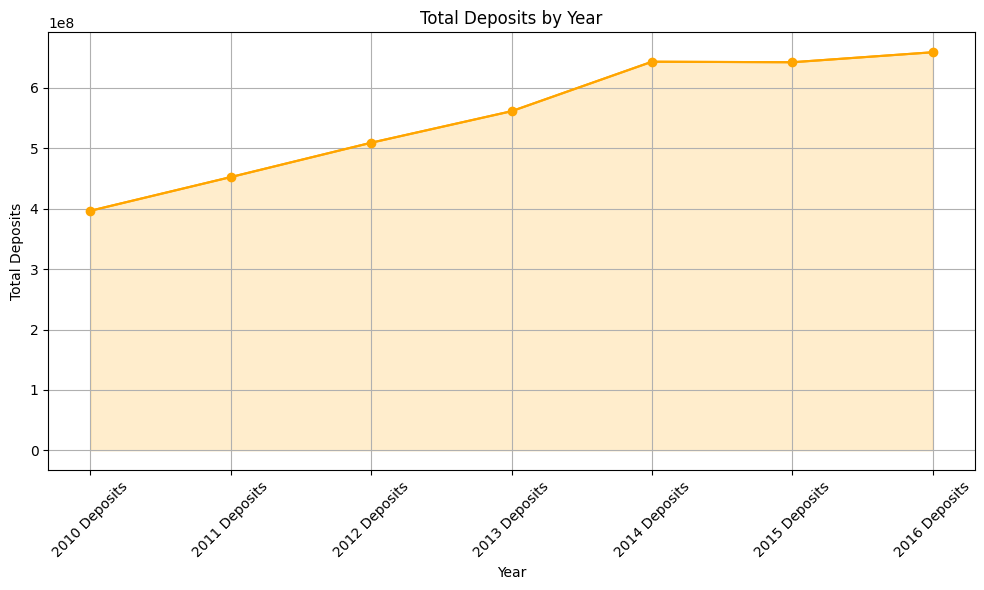

In [24]:
yearly_totals.plot(kind='line', figsize=(10,6), title='Total Deposits by Year', color='Orange')
plt.xlabel('Year')  
plt.plot(yearly_totals.index, yearly_totals.values, marker='o', color='Orange')
plt.fill_between(yearly_totals.index, yearly_totals.values, alpha=0.2, color='Orange')
plt.ylabel('Total Deposits')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top Branches (Performance Ranking)

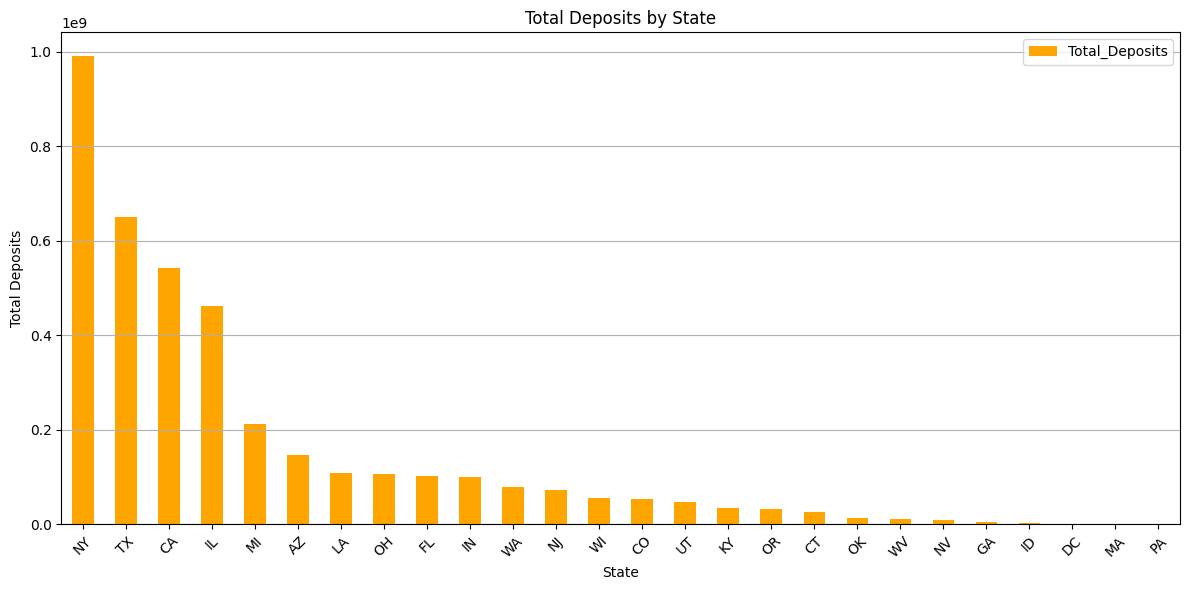

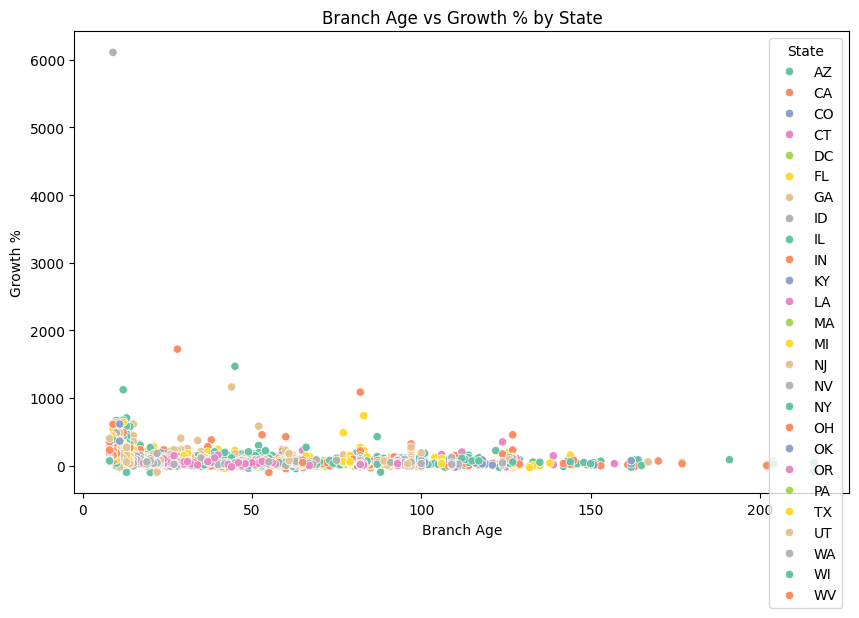

In [18]:
state_summary.plot(kind='bar', y='Total_Deposits', figsize=(12,6), title='Total Deposits by State', color='Orange')
plt.xlabel('State')
plt.ylabel('Total Deposits')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,6))
sns.scatterplot(data=Chase, x='Branch_Age', y='Growth_%', hue='State', palette='Set2')
plt.title('Branch Age vs Growth % by State')
plt.xlabel('Branch Age')
plt.ylabel('Growth %')
plt.legend(title='State')
plt.show()

Growth % Distribution

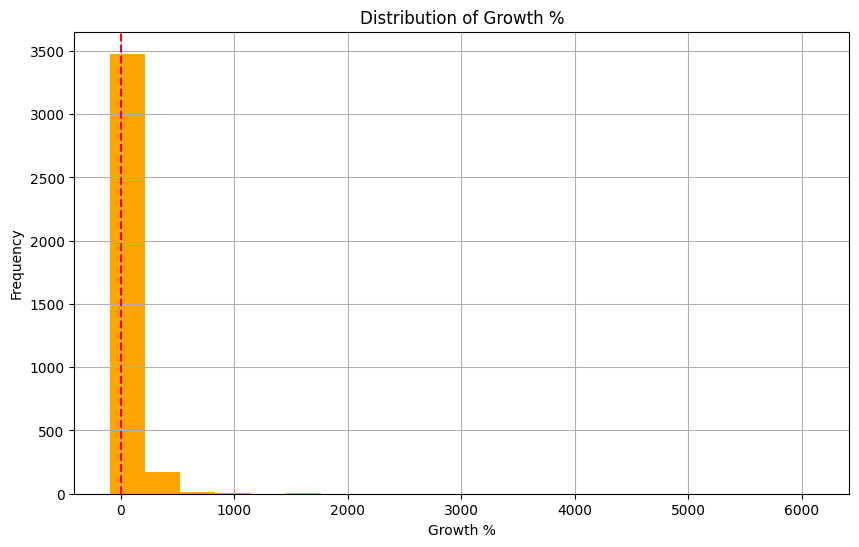

In [19]:
Chase["Growth_%"].plot(kind='hist', bins=20, figsize=(10,6), title='Distribution of Growth %', color='Orange')
plt.xlabel('Growth %')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')  # Add a vertical line at 0% growth
plt.grid()
plt.show()
